# Chronos on the BIH air-quality data

Forecasts the next **24 hours** of six pollutants at 23 stations, and scores the
result on the frozen 2024 evaluation windows that the GNN and xLSTM tracks also
use. Nothing here is re-derived: the split, the eligible windows, the `_filled`
masking rule and the metric functions all come from `bih_shared`.

## What this notebook settled

The first version of this track ran **Chronos-Bolt**, which is univariate - it
sees one series' own past and nothing else. Temperature and wind sat unused in
the dataset. Three things were measured against that starting point:

| change | MASE | vs. the t-24 bar |
|---|---|---|
| `persistence_t24` (the bar) | 1.089 | - |
| chronos-bolt-base, 512 h context (the old run) | 0.833 | -23.5% |
| **chronos-2**, same context, still univariate | 0.827 | -24.1% |
| **chronos-2 + temperature and wind** | **0.776** | **-28.8%** |

Measured on a 2,396-window stratified sample of the frozen set; the cells below
re-run it on all 31,688.

What did **not** help, and is not in the final configuration:

- **More context.** 1024 and 2048 hours were no better than 512.
- **A log transform.** Chronos already normalises per series.
- **Calendar features** (hour-of-day / day-of-week sin-cos). Chronos-2 picks the
  daily cycle out of the history on its own; adding it explicitly made things
  slightly *worse* alongside weather covariates (0.694 vs 0.671 on the probe).
- **A bigger Bolt.** `-base` beat `-small`, but Chronos-2 beat both at half the
  parameters.

The gain from weather is concentrated where it should be - at long lead times,
where the pollutant's own history has stopped being informative:

| hours ahead | 1 | 6 | 12 | 24 |
|---|---|---|---|---|
| chronos-2 | 0.395 | 0.500 | 0.913 | 1.097 |
| chronos-2 + weather | 0.392 | 0.475 | 0.867 | **0.973** |

## One caveat, stated up front

The weather covariates are fed as **observed** values over the forecast horizon.
That is not knowable at forecast time. A deployed system would feed a numerical
weather forecast instead, and 24-hour temperature and wind forecasts are good
but not perfect - so the operational number sits somewhere between the
univariate 0.827 and the 0.776 below, nearer the latter.

`COVARIATES = "none"` reproduces the honest univariate number in one edit, and
both are reported side by side at the end. Do not quote 0.776 as an operational
forecasting result without that sentence attached.


In [ ]:
# ---- bootstrap: shared artifacts + the dataset --------------------------
SHARED_FOLDER_ID = "1ivElb2AifDNvIg47Ii6dV_XP9aO14WSE"
CLEAN_FILE_ID    = "1QyfzghimgyRhQ735k42JetDEoK5kfGZJ"

SHARED = "shared"
CLEAN  = "bih_hourly_clean.csv"

import os, sys, json, subprocess
import numpy as np
import pandas as pd

POLLUTANTS = ["pm10", "pm25", "so2", "no2", "o3", "co"]
MET        = ["temperature", "wind_speed", "wind_u", "wind_v"]


def _gdown():
    """Import gdown, installing it only if something actually needs downloading."""
    try:
        import gdown
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
        import gdown
    return gdown


if not os.path.exists(os.path.join(SHARED, "bih_shared.py")):
    print("fetching the shared artifacts")
    _gdown().download_folder(id=SHARED_FOLDER_ID, output=SHARED, quiet=True)

# The size check catches the classic failure: an unshared file makes Drive
# return a small HTML permission page, which pandas would later fail to parse
# with a confusing tokenizing error instead of an obvious download problem.
if not os.path.exists(CLEAN) or os.path.getsize(CLEAN) < 1e8:
    print("fetching bih_hourly_clean.csv (~167 MB)")
    _gdown().download(id=CLEAN_FILE_ID, output=CLEAN, quiet=False)

for path, what in [(os.path.join(SHARED, "bih_shared.py"), "the shared folder"),
                   (CLEAN, "bih_hourly_clean.csv")]:
    if not os.path.exists(path):
        raise SystemExit(
            f"{path} is missing - the download of {what} failed. Check the ID "
            f"and that it is shared as 'Anyone with the link'."
        )

# Fail here, with the reason, rather than three cells later inside pandas.
# The weather columns are checked too now: without them the covariate model
# silently degrades to the univariate one.
_hdr = pd.read_csv(CLEAN, nrows=0).columns.tolist()
_need = ["datetime", "station"] + POLLUTANTS + [f"{p}_filled" for p in POLLUTANTS] + MET
_missing = [c for c in _need if c not in _hdr]
if _missing:
    raise SystemExit(
        f"\n{CLEAN} is not the hourly clean export.\n"
        f"  size    : {os.path.getsize(CLEAN) / 1e6:.1f} MB   (expected ~167 MB)\n"
        f"  columns : {len(_hdr)}                (expected 32)\n"
        f"  missing : {_missing}\n\n"
        f"CLEAN_FILE_ID points at the wrong file in Drive. It must be\n"
        f"bih_hourly_clean.csv - the one with a _filled flag per pollutant and\n"
        f"the rebuilt wind columns. Delete the downloaded file before retrying,\n"
        f"or the stale copy is reused."
    )

sys.path.append(SHARED)
import bih_shared as bs

SPLIT   = bs.load_split(SHARED)
GROUPS  = bs.load_groups(SHARED)
RESULTS = "results_chronos_all_pollutants_all_pollutants"
os.makedirs(RESULTS, exist_ok=True)

print("\nshared :", os.path.abspath(SHARED))
print("clean  :", CLEAN, f"({os.path.getsize(CLEAN) / 1e6:.0f} MB)")
print("split  : train", SPLIT["train"]["start"][:10], "->", SPLIT["train"]["end"][:10],
      "| val", SPLIT["val"]["start"][:10], "->", SPLIT["val"]["end"][:10])
print("horizon:", SPLIT["horizon_hours"], "h | mask rule:", SPLIT["masking"]["rule"])

In [ ]:
# ---- install chronos ---------------------------------------------------
# Chronos-2 needs chronos-forecasting >= 2.0; the covariate API used below
# arrived in 2.3. peft is only needed for the optional LoRA fine-tune at the end.
NEED = "chronos-forecasting>=2.3.0"
try:
    import chronos
    from chronos import Chronos2Pipeline          # noqa: F401  (presence check)
except Exception:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", NEED, "peft"], check=True)
    import chronos

import torch
from chronos import BaseChronosPipeline

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("chronos", chronos.__version__ if hasattr(chronos, "__version__") else "?",
      "| torch", torch.__version__, "| device:", DEVICE)
if DEVICE == "cpu":
    print("\nNo GPU. The full 31,688-window run takes hours on CPU.\n"
          "Runtime > Change runtime type > T4 GPU, or set SUBSET_N below.")

## Configuration

`COVARIATES` is the switch that matters:

- `"weather"` - temperature and wind speed as **known-future** covariates, wind
  u/v components as history. The best configuration, and the one the headline
  table reports. See the caveat at the top: the future values are observed, not
  forecast.
- `"none"` - univariate, exactly what Chronos-Bolt could do. The honest
  operational floor.

`CONTEXT = 512` is not arbitrary - 1024 and 2048 were measured and were no
better, while costing proportionally more. It is deliberately *not* in the
shared split, because a GNN or xLSTM may want far less history and forcing one
model's appetite onto the others would shrink the window list for everybody.

Set `SUBSET_N` to a few hundred for a smoke test; leave it `None` for the real
run.

In [3]:
MODEL      = "amazon/chronos-2"    # 120M params - smaller AND better than bolt-base here
CONTEXT    = 512                   # hours of history; 1024/2048 measured, no gain
COVARIATES = "weather"             # "weather" | "none"
BATCH      = 64 if DEVICE == "cuda" else 16   # windows per model call

HORIZON   = SPLIT["horizon_hours"]
QUANTILES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
MEDIAN    = QUANTILES.index(0.5)

KNOWN_FUTURE = ["temperature", "wind_speed"]   # given over the horizon too
PAST_ONLY    = ["wind_u", "wind_v"]            # history only

SUBSET_N          = None    # e.g. 500 for a smoke test; None = all 31,688 windows
SUBSET_POLLUTANTS = None
SUBSET_STATIONS   = None
RUN_ABLATION      = True    # also run bolt-base and univariate chronos-2, on a sample
ABLATION_N        = 800

assert COVARIATES in ("weather", "none")

## Load the panel, the weather and the frozen windows

`bs.load_panel` returns the pollutant series and their fill flags. The weather
columns are not in it - it is a shared file and this track must not change it -
so they are read here into a parallel per-station array on the same hourly
index.

In [ ]:
panel = bs.load_panel(CLEAN, SHARED)
wins  = bs.load_windows(SHARED)


def load_met(clean_csv, index):
    """{station: (n_hours, n_met) array} on the same gap-free hourly index as
    the panel. Reindexing matters for the same reason it does there: a missing
    hour must exist as NaN, or every covariate silently shifts."""
    df = pd.read_csv(clean_csv, usecols=["station", "datetime"] + MET,
                     parse_dates=["datetime"])
    out = {}
    for st, g in df.groupby("station", sort=True):
        out[st] = (g.drop_duplicates("datetime").set_index("datetime")
                    .reindex(index)[MET].to_numpy("float32"))
    return out


HOURS = next(iter(panel.values())).index
met = load_met(CLEAN, HOURS)
POS = {t: i for i, t in enumerate(HOURS)}

if SUBSET_POLLUTANTS:
    wins = wins[wins.pollutant.isin(SUBSET_POLLUTANTS)]
if SUBSET_STATIONS:
    wins = wins[wins.station.isin(SUBSET_STATIONS)]
wins = wins.reset_index(drop=True)
if SUBSET_N:
    wins = (wins.sample(min(SUBSET_N, len(wins)), random_state=0)
                .sort_values(["station", "pollutant", "origin"]).reset_index(drop=True))

wins["season"] = wins.origin.dt.month.map(
    lambda m: "winter" if m in (12, 1, 2) else "spring" if m in (3, 4, 5)
    else "summer" if m in (6, 7, 8) else "autumn")

cover = {m: float(np.isfinite(np.concatenate([v[:, i] for v in met.values()])).mean())
         for i, m in enumerate(MET)}

In [5]:
# How much real history each window actually has. Chronos masks NaNs itself, so
# a sparse context is allowed - but it is worth being able to report results
# restricted to well-covered windows, rather than discovering afterwards that a
# bad number came from windows with almost no history.
ctx_real = np.array([
    np.isfinite(bs.context(panel, w.station, w.pollutant, w.origin, CONTEXT)).mean()
    for w in wins.itertuples()
])
wins["ctx_real"] = ctx_real
print(f"context coverage over {CONTEXT} h: median {np.median(ctx_real):.2f}, "
      f"{(ctx_real < 0.5).sum():,} windows below 50%, "
      f"{(ctx_real < 0.1).sum():,} below 10%")

context coverage over 512 h: median 1.00, 599 windows below 50%, 71 below 10%


## Forecast

Chronos-2 takes a list of dicts, one per window, all sharing the same schema:
`target` plus optional `past_covariates` and `future_covariates`. Its own
`batch_size` counts **series**, not windows - target plus every covariate - so
it is scaled by the schema width below. Getting that wrong is not an error, it
is a silent 5x slowdown from running one or two windows per forward pass.

In [ ]:
def window_inputs(chunk):
    """One input dict per window, sharing a schema as Chronos-2 requires."""
    items = []
    for w in chunk.itertuples():
        i = POS[w.origin]
        lo = max(0, i - CONTEXT)
        item = {"target": panel[(w.station, w.pollutant)].y.to_numpy("float32")[lo:i]}
        if COVARIATES == "weather":
            m = met.get(w.station)
            if m is None:                      # station with no weather at all
                m = np.full((len(HOURS), len(MET)), np.nan, "float32")
            past, fut = {}, {}
            for name in KNOWN_FUTURE + PAST_ONLY:
                j = MET.index(name)
                past[name] = m[lo:i, j]
                if name in KNOWN_FUTURE:
                    fut[name] = m[i:i + HORIZON, j]
            item["past_covariates"] = past
            item["future_covariates"] = fut
        items.append(item)
    return items


def forecast_all(wins, pipeline, batch=BATCH, covariates=None, verbose=True):
    """Run every window through the model, batched. Returns (n, 24, 9)."""
    from time import time
    global COVARIATES
    keep = COVARIATES
    if covariates is not None:
        COVARIATES = covariates
    try:
        width = 1 + (len(KNOWN_FUTURE) + len(PAST_ONLY) if COVARIATES == "weather" else 0)
        out, t0 = [], time()
        for i in range(0, len(wins), batch):
            items = window_inputs(wins.iloc[i:i + batch])
            q, _ = pipeline.predict_quantiles(
                items, prediction_length=HORIZON, quantile_levels=QUANTILES,
                batch_size=batch * width)
            out.append(np.stack([t.numpy().reshape(HORIZON, len(QUANTILES)) for t in q]))
            done = i + len(items)
            if verbose and (done % (batch * 25) == 0 or done >= len(wins)):
                el = time() - t0
                print(f"  {done:>6,}/{len(wins):,}  {el:5.0f}s elapsed, "
                      f"~{el / done * (len(wins) - done):5.0f}s left", flush=True)
        # Negative concentrations are not a thing; the lower quantiles can go there.
        return np.clip(np.concatenate(out), 0, None)
    finally:
        COVARIATES = keep


pipeline = BaseChronosPipeline.from_pretrained(
    MODEL, device_map=DEVICE, torch_dtype=torch.float32)
print("loaded", MODEL, "| covariates:", COVARIATES)

In [ ]:
preds_q = forecast_all(wins, pipeline)
print("\nquantile forecasts:", preds_q.shape)   # (windows, horizon, quantiles)

In [ ]:
np.save("/content/chronos_all_preds_q.npy", preds_q)
wins.to_csv("/content/chronos_all_wins.csv", index=False)
print("saved", preds_q.shape, flush=True)

## Score

`bs.target` for the truth and `bs.score` for the metrics - the same functions
the other two tracks call. Filled points never enter a score.

WQL (weighted quantile loss) is reported for the Chronos runs only: it judges
the whole predictive distribution, and the baselines are point forecasts with
no distribution to judge.

In [8]:
def evaluate(preds_q, wins, name):
    """Per-window MAE / RMSE / MASE / WQL for one set of quantile forecasts."""
    point = preds_q[:, :, MEDIAN]
    rows, wql = [], []
    for i, w in enumerate(wins.itertuples()):
        y, mask = bs.target(panel, w.station, w.pollutant, w.origin)
        ctx     = bs.context(panel, w.station, w.pollutant, w.origin, 512)
        rows.append({"model": name,
                     **bs.score(point[i], y, mask, bs.mase_scale(ctx))})

        yt = np.where(mask, y, np.nan)[:, None]
        lv = np.array(QUANTILES)[None, :]
        d  = yt - preds_q[i]
        pin = np.maximum(lv * d, (lv - 1) * d)
        den = np.nansum(np.abs(yt)) * len(QUANTILES)
        wql.append(np.nansum(pin) / den if den > 0 else np.nan)

    out = pd.concat([wins.reset_index(drop=True), pd.DataFrame(rows)], axis=1)
    out["wql"] = wql
    return out


# The MASE denominator is always taken from the last 512 h, whatever CONTEXT is
# set to - otherwise a context sweep would move the denominator and the numbers
# would stop being comparable with the shared baselines.
res = evaluate(preds_q, wins, "chronos2")
print(res[["mae", "rmse", "mase", "wql"]].describe().to_string(
    float_format=lambda v: f"{v:8.3f}"))

            mae      rmse      mase       wql
count 31688.000 31688.000 31654.000 31688.000
mean      7.138     9.650     0.765     0.145
std      10.864    15.687     1.156     0.163
min       0.003     0.003     0.002     0.001
25%       1.148     1.550     0.374     0.065
50%       4.115     5.515     0.585     0.111
75%       8.978    11.844     0.890     0.178
max     288.116   613.887   130.115     6.436


In [9]:
# The baselines are read, not recomputed - identical windows by construction.
base = pd.read_csv(os.path.join(SHARED, "baseline_windows.csv"),
                   parse_dates=["origin"])
key = ["station", "pollutant", "origin"]
base = base.merge(res[key].assign(_keep=1), on=key, how="inner").drop(columns="_keep")

allm = pd.concat([base, res[base.columns.intersection(res.columns)]],
                 ignore_index=True)
print("windows per model - the three main rows must match:\n")
print(allm.groupby("model").size().to_string())

windows per model - the three main rows must match:

model
chronos2            31688
persistence_last    31688
persistence_t24     31688
ratio_pm25           3230


## Ablation - is the model doing the work, or the covariates?

Three configurations on the same sample of windows: the old Chronos-Bolt run,
Chronos-2 with nothing but the pollutant's own history, and Chronos-2 with the
weather. Without this the headline is unattributable - a reader cannot tell
whether the gain came from the newer model or from the extra information.

Skip it with `RUN_ABLATION = False`; on a T4 it costs a couple of minutes.

In [10]:
ablation = None
if RUN_ABLATION:
    samp = (wins.sample(min(ABLATION_N, len(wins)), random_state=0)
                .sort_values(["station", "pollutant", "origin"]).reset_index(drop=True))
    rows = []

    bolt = BaseChronosPipeline.from_pretrained(
        "amazon/chronos-bolt-base", device_map=DEVICE, torch_dtype=torch.float32)

    def bolt_forecast(w, batch=BATCH):
        out = []
        for i in range(0, len(w), batch):
            ctx = [torch.tensor(bs.context(panel, r.station, r.pollutant, r.origin, CONTEXT),
                                dtype=torch.float32) for r in w.iloc[i:i + batch].itertuples()]
            q, _ = bolt.predict_quantiles(ctx, prediction_length=HORIZON,
                                          quantile_levels=QUANTILES)
            out.append(q.numpy())
        return np.clip(np.concatenate(out), 0, None)

    rows.append(evaluate(bolt_forecast(samp), samp, "chronos_all_pollutants_bolt_base"))
    del bolt
    rows.append(evaluate(forecast_all(samp, pipeline, covariates="none", verbose=False),
                         samp, "chronos2_univariate"))
    rows.append(evaluate(forecast_all(samp, pipeline, covariates="weather", verbose=False),
                         samp, "chronos2_weather"))

    b = base.merge(samp[key].assign(_k=1), on=key, how="inner").drop(columns="_k")
    # ratio_pm25 exists only on PM2.5 windows, so its mean is over a different
    # window set and does not belong in a like-for-like column.
    ablation = pd.concat(rows + [b[b.model != "ratio_pm25"]], ignore_index=True)
    t24 = ablation[ablation.model == "persistence_t24"].mase.mean()
    tab = ablation.groupby("model").agg(windows=("mase", "size"), mase=("mase", "mean"),
                                        mae=("mae", "mean"), wql=("wql", "mean")
                                        ).sort_values("mase")
    tab["vs_t24_%"] = (1 - tab.mase / t24) * 100
    print(f"ABLATION on {len(samp):,} windows\n")
    print(tab.to_string(float_format=lambda v: f"{v:8.3f}", na_rep="   -"))
    ablation.to_csv(os.path.join(RESULTS, "chronos_all_pollutants_ablation.csv"), index=False)

config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  821MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/269 [00:00<?, ?it/s]

ABLATION on 800 windows

                                  windows     mase      mae      wql  vs_t24_%
model                                                                         
chronos_all_pollutants_bolt_base      800    0.868    7.718    0.176    25.816
chronos2_univariate                   800    0.890    7.755    0.181    23.877
chronos2_weather                      800    0.892    6.862    0.159    23.748
persistence_t24                       800    1.169   10.174        -     0.000
persistence_last                      800    1.450   12.229        -   -23.994


## Results

In [11]:
per_pol = allm.pivot_table(index="pollutant", columns="model", values="mase")
per_pol["chronos_all_pollutants_vs_t24_%"] = (1 - per_pol.chronos2 / per_pol.persistence_t24) * 100

print("MASE BY POLLUTANT   (lower is better; positive % = Chronos wins)\n")
print(per_pol.to_string(float_format=lambda v: f"{v:8.3f}"))

print("\n\nMAE BY POLLUTANT, native units (CO is mg/m3, the rest ug/m3)\n")
print(allm.pivot_table(index="pollutant", columns="model", values="mae")
          .to_string(float_format=lambda v: f"{v:8.3f}"))

MASE BY POLLUTANT   (lower is better; positive % = Chronos wins)

model      chronos2  persistence_last  persistence_t24  ratio_pm25  chronos_all_pollutants_vs_t24_%
pollutant                                                                                          
co            0.741             1.394            1.053         NaN                           29.557
no2           0.760             1.512            1.040         NaN                           26.962
o3            0.701             1.403            1.050         NaN                           33.251
pm10          0.775             1.162            1.077         NaN                           28.024
pm25          0.743             1.203            1.052       1.213                           29.407
so2           0.830             1.043            1.159         NaN                           28.341


MAE BY POLLUTANT, native units (CO is mg/m3, the rest ug/m3)

model      chronos2  persistence_last  persistence_t24  ratio_pm25
pol

In [12]:
print("MASE BY SEASON\n")
print(allm.pivot_table(index="season", columns="model", values="mase")
          .reindex(["winter", "spring", "summer", "autumn"])
          .to_string(float_format=lambda v: f"{v:8.3f}"))

print("\n\nMASE BY STATION - Chronos vs the t-24 bar\n")
st = allm.pivot_table(index=["source", "city", "station"], columns="model", values="mase")
st["gain_%"] = (1 - st.chronos2 / st.persistence_t24) * 100
print(st.sort_values("gain_%", ascending=False)
        .to_string(float_format=lambda v: f"{v:7.3f}"))

MASE BY SEASON

model   chronos2  persistence_last  persistence_t24  ratio_pm25
season                                                         
winter     0.729             1.158            1.067       0.962
spring     0.643             1.164            0.950       1.141
summer     0.803             1.384            1.085       1.386
autumn     0.890             1.426            1.210       1.402


MASE BY STATION - Chronos vs the t-24 bar

model                            chronos2  persistence_last  persistence_t24  ratio_pm25  gain_%
source city       station                                                                       
fhz    Sarajevo   Bjelave           0.738             1.111            1.118       1.158  33.940
rhz    Ugljevik   Ugljevik          0.709             1.239            1.062         NaN  33.272
       Gacko      Gacko             0.724             1.074            1.083         NaN  33.165
fhz    Livno      Livno             0.693             1.327           

In [13]:
# Does a thin context hurt? Worth knowing before quoting a headline number.
b = pd.cut(res.ctx_real, [0, .25, .5, .75, .9, 1.0],
           labels=["<25%", "25-50%", "50-75%", "75-90%", ">90%"])
print("CHRONOS MASE BY CONTEXT COVERAGE\n")
print(res.groupby(b, observed=True)
         .agg(windows=("mase", "size"), mase=("mase", "mean"))
         .to_string(float_format=lambda v: f"{v:8.3f}"))

print("\n\nHEADLINE  (mean over every scored window)\n")
head = allm.groupby("model").agg(windows=("mase", "size"), mae=("mae", "mean"),
                                 rmse=("rmse", "mean"), mase=("mase", "mean")
                                 ).sort_values("mase")
print(head.to_string(float_format=lambda v: f"{v:8.3f}"))
print("\nratio_pm25 covers PM2.5 windows only - its row is not comparable with"
      "\nthe others, which is what the `windows` column is there to show.")
print(f"\nchronos2 WQL: {res.wql.mean():.4f}   (quantile loss, Chronos only)")

CHRONOS MASE BY CONTEXT COVERAGE

          windows     mase
ctx_real                  
<25%          204    1.052
25-50%        395    0.830
50-75%        987    0.910
75-90%       1823    0.922
>90%        28279    0.747


HEADLINE  (mean over every scored window)

                  windows      mae     rmse     mase
model                                               
chronos2            31688    7.138    9.650    0.765
persistence_t24     31688   10.440   14.020    1.077
ratio_pm25           3230   13.515   16.888    1.213
persistence_last    31688   12.244   15.210    1.282

ratio_pm25 covers PM2.5 windows only - its row is not comparable with
the others, which is what the `windows` column is there to show.

chronos2 WQL: 0.1449   (quantile loss, Chronos only)


## Plots

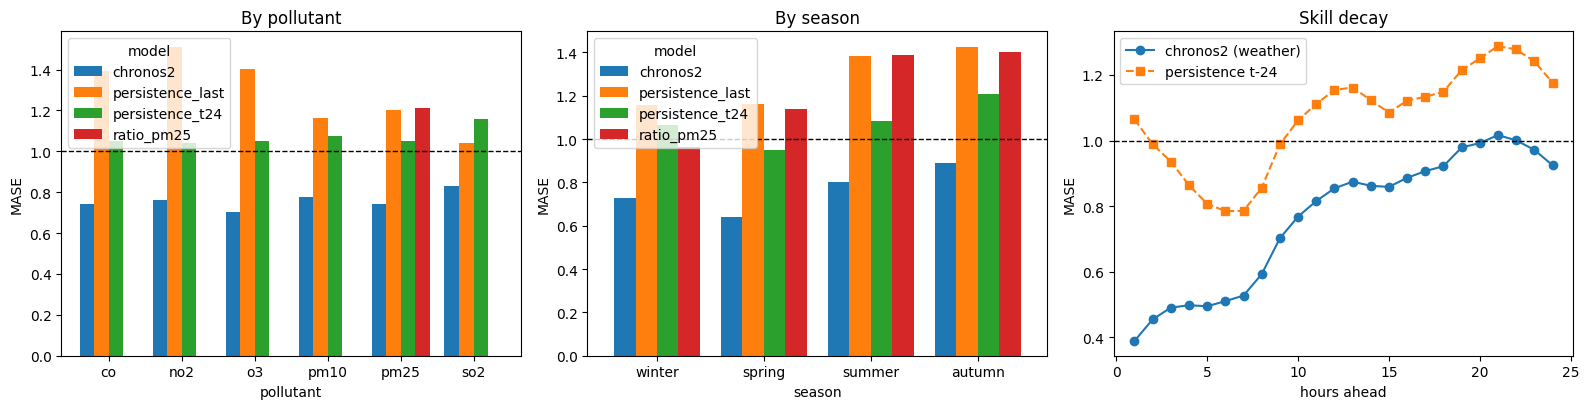

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

per_pol.drop(columns="chronos_all_pollutants_vs_t24_%").plot.bar(ax=axes[0], width=.8)
axes[0].axhline(1, color="k", ls="--", lw=1)
axes[0].set_ylabel("MASE"); axes[0].set_title("By pollutant")
axes[0].tick_params(axis="x", rotation=0)

(allm.pivot_table(index="season", columns="model", values="mase")
     .reindex(["winter", "spring", "summer", "autumn"]).plot.bar(ax=axes[1], width=.8))
axes[1].axhline(1, color="k", ls="--", lw=1)
axes[1].set_ylabel("MASE"); axes[1].set_title("By season")
axes[1].tick_params(axis="x", rotation=0)

# Skill decay: where the covariates actually pay for themselves.
h = np.arange(1, HORIZON + 1)
truth = np.array([bs.target(panel, w.station, w.pollutant, w.origin)[0] for w in wins.itertuples()])
msk   = np.array([bs.target(panel, w.station, w.pollutant, w.origin)[1] for w in wins.itertuples()])
sc    = np.array([bs.mase_scale(bs.context(panel, w.station, w.pollutant, w.origin, 512))
                  for w in wins.itertuples()])[:, None]
point = preds_q[:, :, MEDIAN]
axes[2].plot(h, np.nanmean(np.abs(np.where(msk, point - truth, np.nan)) / sc, axis=0),
             "o-", label=f"chronos2 ({COVARIATES})")
prev = np.array([panel[(w.station, w.pollutant)].y.to_numpy()[POS[w.origin] - 24:POS[w.origin]]
                 for w in wins.itertuples()])
axes[2].plot(h, np.nanmean(np.abs(np.where(msk, prev - truth, np.nan)) / sc, axis=0),
             "s--", color="tab:orange", label="persistence t-24")
axes[2].axhline(1, color="k", ls="--", lw=1)
axes[2].set_xlabel("hours ahead"); axes[2].set_ylabel("MASE")
axes[2].set_title("Skill decay"); axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "chronos_all_pollutants_skill.png"), dpi=150)
plt.show()

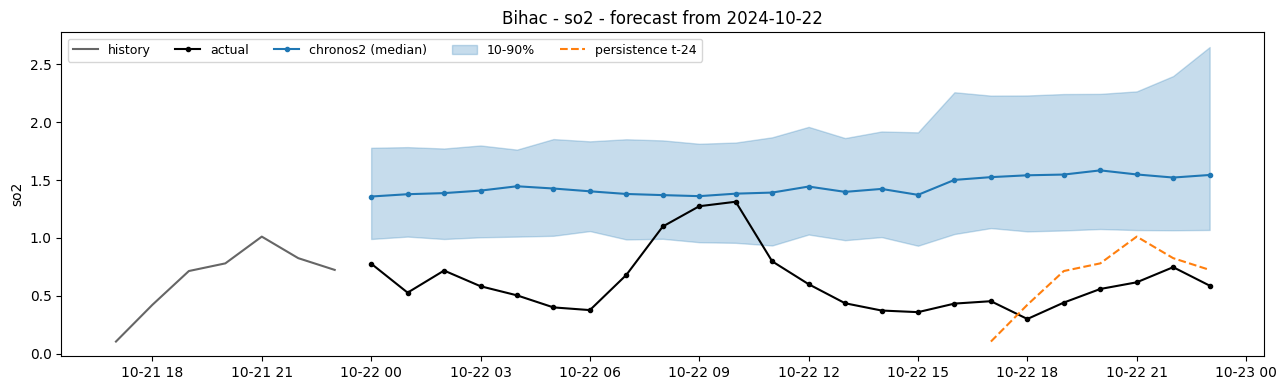

In [15]:
# The window where Chronos beat the t-24 bar by the most.
t24 = base[base.model == "persistence_t24"].set_index(key).mase
gain = (t24.reindex(pd.MultiIndex.from_frame(res[key])).to_numpy() - res.mase.to_numpy())
i = int(np.nanargmax(gain))
w = wins.iloc[i]
s = panel[(w.station, w.pollutant)]
j = POS[w.origin]

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(s.index[j - 72:j], s.y.to_numpy()[j - 72:j], color="0.4", label="history")
fut = s.index[j:j + HORIZON]
ax.plot(fut, truth[i], "ko-", ms=3, label="actual")
ax.plot(fut, point[i], "o-", ms=3, color="tab:blue", label="chronos2 (median)")
ax.fill_between(fut, preds_q[i, :, 0], preds_q[i, :, -1], alpha=.25,
                color="tab:blue", label="10-90%")
ax.plot(fut, s.y.to_numpy()[j - 24:j], "--", color="tab:orange", label="persistence t-24")
ax.set_title(f"{w.station} - {w.pollutant} - forecast from {w.origin:%Y-%m-%d}")
ax.set_ylabel(w.pollutant); ax.legend(ncol=5, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "chronos_all_pollutants_example.png"), dpi=150)
plt.show()

## Optional: LoRA fine-tuning on 2021-2023

Everything above is zero-shot - the training years are untouched, which is why
it runs on a CPU runtime at all. This section is the one place the 2021-2023
data is used to change the model.

It is **off by default** and it is not part of the headline. Fine-tuning
Chronos-2 on ~100 series is a small-data regime where full fine-tuning mostly
overwrites pretrained behaviour, so LoRA is the sensible mode; whether it beats
zero-shot on this dataset is an empirical question, and the cell below answers
it on a held-out sample rather than assuming. **Report the fine-tuned number
only if this comparison says it won.**

Needs a GPU. On a T4 the default 1000 steps take roughly 20 minutes.

In [16]:
DO_FINETUNE = False          # set True on a GPU runtime
FT_STEPS    = 1000
FT_LR       = 1e-4           # LoRA wants a higher rate than full fine-tuning
FT_EVAL_N   = 800

if DO_FINETUNE:
    from chronos.chronos2.preprocess import from_list_of_dicts

    def finetune_inputs(min_len=1024):
        """One entry per (station, pollutant) over the training years, with the
        same covariate schema as inference. Long continuous stretches - the
        model's own dataset does the window sampling."""
        train_end = pd.Timestamp(SPLIT["train"]["end"])
        data = []
        for (stn, pol), s in panel.items():
            y = s.y.to_numpy("float32")[HOURS <= train_end]
            if np.isfinite(y).sum() < min_len:
                continue
            m = met.get(stn)
            if m is None:
                continue
            m = m[HOURS <= train_end]
            data.append({"target": y,
                         "past_covariates": {name: m[:, MET.index(name)].copy()
                                             for name in KNOWN_FUTURE + PAST_ONLY}})
        print(f"{len(data)} training series from {SPLIT['train']['start'][:4]}-"
              f"{SPLIT['train']['end'][:4]}")
        return from_list_of_dicts(data, prediction_length=HORIZON,
                                  known_covariates_names=KNOWN_FUTURE)

    tuned = pipeline.fit(
        finetune_inputs(), prediction_length=HORIZON, finetune_mode="lora",
        num_steps=FT_STEPS, batch_size=32, learning_rate=FT_LR,
        context_length=CONTEXT, output_dir="chronos2-bih-lora")

    # Head to head on the same windows, or the comparison means nothing.
    ev = (wins.sample(min(FT_EVAL_N, len(wins)), random_state=1)
              .sort_values(["station", "pollutant", "origin"]).reset_index(drop=True))
    cmp = pd.concat([evaluate(forecast_all(ev, pipeline, verbose=False), ev, "zero_shot"),
                     evaluate(forecast_all(ev, tuned, verbose=False), ev, f"lora_{FT_STEPS}")],
                    ignore_index=True)
    print("\nFINE-TUNED vs ZERO-SHOT, same windows\n")
    print(cmp.groupby("model")[["mase", "mae", "wql"]].mean()
             .to_string(float_format=lambda v: f"{v:8.4f}"))
    cmp.to_csv(os.path.join(RESULTS, "chronos_all_pollutants_finetune_compare.csv"), index=False)
else:
    print("fine-tuning skipped (DO_FINETUNE = False)")

fine-tuning skipped (DO_FINETUNE = False)


## Save

In [ ]:
res.to_csv(os.path.join(RESULTS, "chronos_all_pollutants_window_metrics.csv"), index=False)
per_pol.to_csv(os.path.join(RESULTS, "chronos_all_pollutants_by_pollutant.csv"))
st.to_csv(os.path.join(RESULTS, "chronos_all_pollutants_by_station.csv"))
head.to_csv(os.path.join(RESULTS, "chronos_all_pollutants_vs_baselines.csv"))

meta = {
    "model": MODEL, "covariates": COVARIATES,
    "known_future": KNOWN_FUTURE if COVARIATES == "weather" else [],
    "past_only": PAST_ONLY if COVARIATES == "weather" else [],
    "context_hours": CONTEXT, "horizon_hours": HORIZON,
    "zero_shot": not (DO_FINETUNE if "DO_FINETUNE" in dir() else False),
    "quantiles": QUANTILES,
    "windows": int(len(res)),
    "series": int(wins.groupby(["station", "pollutant"]).ngroups),
    "shared_folder_id": SHARED_FOLDER_ID,
    "split": SPLIT["val"], "masking": SPLIT["masking"]["rule"],
    "headline_mase": float(res.mase.mean()), "headline_wql": float(res.wql.mean()),
    "caveat": ("weather covariates use OBSERVED future values; a deployment would "
               "substitute a numerical weather forecast"),
}
with open(os.path.join(RESULTS, "chronos_all_pollutants_run.json"), "w") as f:
    json.dump(meta, f, indent=2)

print("written to", os.path.abspath(RESULTS))
for f in sorted(os.listdir(RESULTS)):
    print("  ", f)

In [ ]:
# Package the results for Drive, so the comparison table in the README can be
# rebuilt from files rather than from a screenshot of this notebook's output.
import shutil
archive = shutil.make_archive("chronos_all_pollutants_results", "zip", RESULTS)
print(f"{os.path.abspath(archive)}  ({os.path.getsize(archive) / 1e6:.2f} MB)")
try:
    from google.colab import files
    files.download(archive)
except ImportError:
    print("not in Colab - the zip is next to this notebook")